In [225]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [226]:
id_list = [925, 165, 9, 477, 291, 162] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

In [227]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 9

In [228]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [229]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [230]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_53512\2960187605.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_53512\2960187605.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_53512\2960187605.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

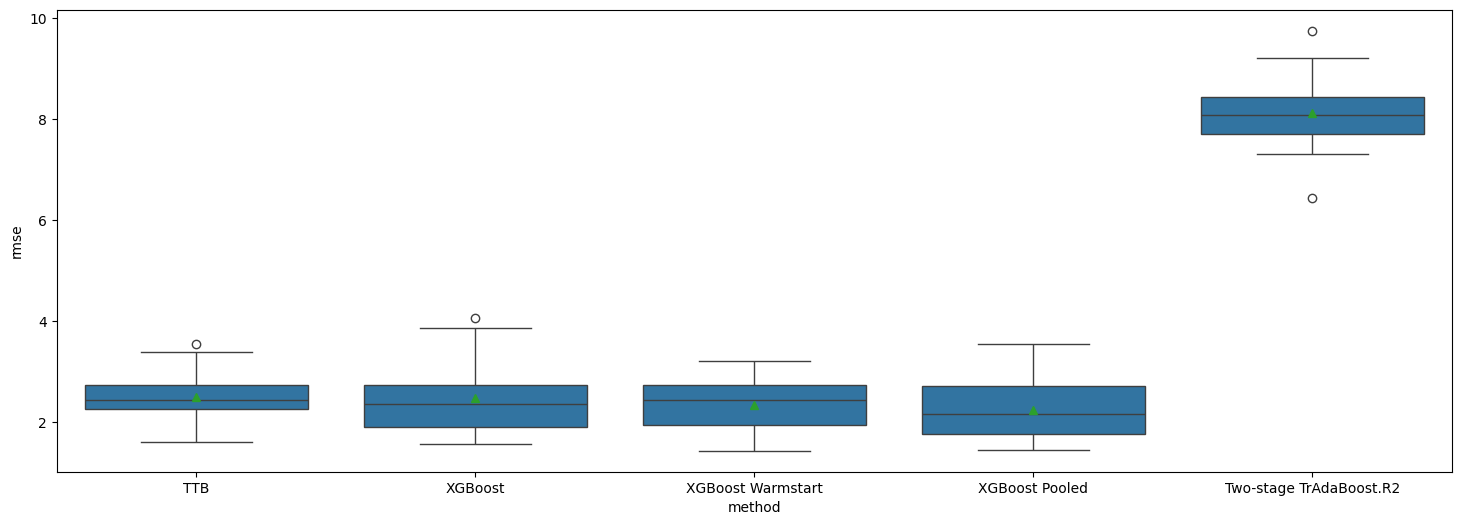

In [231]:
plt.figure(figsize = (18,6))
#Boxplot
dat = pd.read_csv(f'results_new/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
#dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_new/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'


data = pd.read_csv(f'results_new/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_new/xgb_naive_{index}.csv')
xgboost_data_pooled = data
xgboost_data_pooled['method'] = 'XGBoost Pooled'

best_XGBoost_pooled, best_XGBoost_params_pooled = topk_per_d_per_method(
    xgboost_data_pooled,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results/two_trada_{index}.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators'], k=nr_of_seeds
)
best_trada['method'] = 'Two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [232]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1241,0.2,3.0,1.0,0.0,0.5,2.490498,30,877.0,1000.0,2.269598,1.768204,2.240723,1.562213,TransferTreeBoost


In [233]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2218,0.3,1.0,2.489162,30,2226,888.0,2.656142,1.507047,1.868894,1.349664,XGBoost


In [234]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
67,0.2,1.0,2.337014,30,42,860.0,2.034739,1.55575,2.490122,1.666177,XGBoost Warmstart


In [235]:
#Get best params in order
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1770,0.125,2.0,2.244728,30,1716,882.0,1.428001,0.997625,2.886988,2.123218,XGBoost Pooled


In [236]:
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,avg_rmse,n_seeds,Unnamed: 0,seed,tree_size,rmse,mae,method
11,0.1,10.0,7.72568,30,3,860.0,4.0,7.32597,5.503929,two-stage TrAdaBoost.R2


In [237]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(-0.05365381186714423)

In [238]:
l = [7.3393227538710155, 4.735811459752751, 4.979078149374135, 1.164187085102093, 1.0248113183095346, 1.7660984951885783, 12.368571357630206]
import numpy as np
np.mean(l)

np.float64(4.768268659889759)

In [239]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3)
)

2.49 & 0.486 & 2.489 & 0.647 & 2.337 & 0.499 & 2.245 & 0.563


In [240]:
best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

best_LSTransferTreeBoost_params

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_53512\3554403312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'


,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1241,0.2,3.0,1.0,0.00,0.5,2.490498,30,877.0,1000.0,2.269598,1.768204,2.240723,1.562213,TransferTreeBoost
889,0.2,3.0,1.0,0.00,0.5,2.490498,30,872.0,1000.0,2.254873,1.307465,2.681910,1.952604,TransferTreeBoost
374,0.2,3.0,1.0,0.00,0.5,2.490498,30,865.0,1000.0,4.333288,3.439683,2.523159,1.692014,TransferTreeBoost
830,0.2,3.0,1.0,0.00,0.5,2.490498,30,871.0,1000.0,2.402828,1.669361,2.348441,1.833441,TransferTreeBoost
121,0.2,3.0,1.0,0.00,0.5,2.490498,30,861.0,1000.0,3.471741,2.526001,2.299043,1.507779,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,0.3,2.0,2.0,0.01,0.9,4.790104,30,878.0,1000.0,5.253982,4.725582,4.148347,3.548189,TransferTreeBoost
494,0.3,2.0,2.0,0.01,0.9,4.790104,30,866.0,1000.0,6.721664,5.166995,4.157774,3.533374,TransferTreeBoost
1182,0.3,2.0,2.0,0.01,0.9,4.790104,30,876.0,1000.0,5.437544,4.856701,6.498460,5.815519,TransferTreeBoost
2101,0.3,2.0,2.0,0.01,0.9,4.790104,30,889.0,1000.0,7.259409,6.378978,6.316186,5.565788,TransferTreeBoost
